In [2]:
# Network analysis and colored cluster plots for DASS-15 and DASS-21
# Requires: qgraph (uses cor_auto, EBICglasso plotting), igraph suggested
# Paths from your project:
wide_path <- "D:/Research files/Thesis/Smoke_mental_health/Version finals/ANALYSIS/Thesis_PositronR/data/processed/analysis_phase1_ordered.rds"

suppressPackageStartupMessages({
  library(qgraph)   # cor_auto, EBICglasso plotting via qgraph(...)
  library(readr)
})

# 1) Load wide dataset and coerce Likert to numeric 0..3
dat_in <- readRDS(wide_path)
if (is.list(dat_in) && !is.data.frame(dat_in)) {
  if (!is.null(dat_in$resp_dass_num)) dat_in <- as.data.frame(dat_in$resp_dass_num) else
  if (!is.null(dat_in$data))          dat_in <- as.data.frame(dat_in$data) else
    stop("Could not extract a data.frame from analysis_phase1_ordered.rds")
}
to_num <- function(x){
  if (is.factor(x)) as.numeric(as.character(x)) else as.numeric(x)
}

# 2) Define canonical DASS-21 items and your DASS-15 short-form items
canon21 <- c("dQ1S","dQ2A","dQ3D","dQ4A","dQ5D","dQ6S","dQ7A","dQ8S","dQ9A","dQ10D",
             "dQ11S","dQ12S","dQ13D","dQ14S","dQ15A","dQ16D","dQ17D","dQ18S","dQ19A","dQ20A","dQ21D")
sf15 <- c("dQ7A","dQ10D","dQ13D","dQ14S","dQ16D","dQ17D","dQ18S","dQ19A","dQ20A",
          "dQ21D","dQ1S","dQ9A","dQ11S","dQ12S","dQ15A")

stopifnot(all(canon21 %in% names(dat_in)), all(sf15 %in% names(dat_in)))

dat21 <- as.data.frame(lapply(dat_in[, canon21, drop = FALSE], to_num))
dat15 <- as.data.frame(lapply(dat_in[, sf15,   drop = FALSE], to_num))

# 3) Construct group labels for coloring by construct
# For 21: suffix letter denotes subscale (D, A, S)
grp21 <- ifelse(endsWith(canon21, "D"), "Depression",
         ifelse(endsWith(canon21, "A"), "Anxiety", "Stress"))
# For 15: derive from item suffix as well
grp15 <- ifelse(endsWith(sf15, "D"), "Depression",
         ifelse(endsWith(sf15, "A"), "Anxiety", "Stress"))

# Optional: pick colorblind-friendly palette per group
group_colors <- c(Depression = "#1f77b4",  # blue
                  Anxiety    = "#d62728",  # red
                  Stress     = "#2ca02c")  # green

# 4) Estimate polychoric correlations and EBICglasso networks
# qgraph can accept cor_auto output directly; set graph='glasso' with sampleSize
C21 <- cor_auto(dat21)  # polychoric/appropriate correlations
C15 <- cor_auto(dat15)

n21 <- nrow(dat21)
n15 <- nrow(dat15)

# 5) Plot side-by-side networks with colored groups
png("outputs/PhaseC_field/network_DASS21_EBICglasso.png", width = 1400, height = 900, res = 140)
qgraph(C21,
       graph = "glasso",
       sampleSize = n21,
       layout = "spring",
       groups = split(canon21, grp21),       # groups as list by name
       color = unname(group_colors[unique(grp21)]),
       legend = TRUE,
       legend.mode = "names",
       legend.cex = 0.8,
       theme = "colorblind",
       vsize = 6,
       cut = 0,
       details = TRUE,
       title = "DASS-21 EBICglasso (polychoric) colored by construct")
dev.off()

png("outputs/PhaseC_field/network_DASS15_EBICglasso.png", width = 1400, height = 900, res = 140)
qgraph(C15,
       graph = "glasso",
       sampleSize = n15,
       layout = "spring",
       groups = split(sf15, grp15),
       color = unname(group_colors[unique(grp15)]),
       legend = TRUE,
       legend.mode = "names",
       legend.cex = 0.8,
       theme = "colorblind",
       vsize = 6,
       cut = 0,
       details = TRUE,
       title = "DASS-15 EBICglasso (polychoric) colored by construct")
dev.off()

# 6) Optional: arrange both in one viewport (requires gridExtra) — skip if not installed
# library(gridExtra)
# grid.arrange(
#   qgraph(C21, graph="glasso", sampleSize=n21, layout="spring",
#          groups = split(canon21, grp21),
#          color = unname(group_colors[unique(grp21)]),
#          theme="colorblind", vsize=6, cut=0),
#   qgraph(C15, graph="glasso", sampleSize=n15, layout="spring",
#          groups = split(sf15, grp15),
#          color = unname(group_colors[unique(grp15)]),
#          theme="colorblind", vsize=6, cut=0),
#   ncol = 2
# )

cat("Saved: outputs/PhaseC_field/network_DASS21_EBICglasso.png and network_DASS15_EBICglasso.png\n")


Variables detected as ordinal: dQ1S; dQ2A; dQ3D; dQ4A; dQ5D; dQ6S; dQ7A; dQ8S; dQ9A; dQ10D; dQ11S; dQ12S; dQ13D; dQ14S; dQ15A; dQ16D; dQ17D; dQ18S; dQ19A; dQ20A; dQ21D
Variables detected as ordinal: dQ7A; dQ10D; dQ13D; dQ14S; dQ16D; dQ17D; dQ18S; dQ19A; dQ20A; dQ21D; dQ1S; dQ9A; dQ11S; dQ12S; dQ15A


Warning messages:
1: In EBICglassoCore(S = S, n = n, gamma = gamma, penalize.diagonal = penalize.diagonal,  :
  A dense regularized network was selected (lambda < 0.1 * lambda.max). Recent work indicates a possible drop in specificity. Interpret the presence of the smallest edges with care. Setting threshold = TRUE will enforce higher specificity, at the cost of sensitivity.
2: In lcolor[is.na(lcolor)] <- ifelse(vertex.colors == "background",  :
  number of items to replace is not a multiple of replacement length
Warning messages:
1: In EBICglassoCore(S = S, n = n, gamma = gamma, penalize.diagonal = penalize.diagonal,  :
  A dense regularized network was selected (lambda < 0.1 * lambda.max). Recent work indicates a possible drop in specificity. Interpret the presence of the smallest edges with care. Setting threshold = TRUE will enforce higher specificity, at the cost of sensitivity.
2: In lcolor[is.na(lcolor)] <- ifelse(vertex.colors == "background",  :
  number of items to replace is

Saved: outputs/PhaseC_field/network_DASS21_EBICglasso.png and network_DASS15_EBICglasso.png


In [3]:
# DASS21_network_colored.R

suppressPackageStartupMessages({
  library(readr); library(dplyr)
  library(qgraph)      # plotting + EBICglasso
  library(bootnet)     # estimation helper (optional)
})

# File from your repo listing
wide_path <- "D:/Research files/Thesis/Smoke_mental_health/Version finals/ANALYSIS/Thesis_PositronR/data/processed/analysis_phase1_ordered.rds"
dat <- readRDS(wide_path)

# Convert container if needed
if (is.list(dat) && !is.data.frame(dat)) {
  if (!is.null(dat$resp_dass_num)) dat <- as.data.frame(dat$resp_dass_num) else
  if (!is.null(dat$data)) dat <- as.data.frame(dat$data)
}

# Canonical DASS-21 item IDs (7 each)
dep <- c("dQ3D","dQ5D","dQ10D","dQ13D","dQ16D","dQ17D","dQ21D")
anx <- c("dQ2A","dQ4A","dQ7A","dQ9A","dQ15A","dQ19A","dQ20A")
str <- c("dQ1S","dQ6S","dQ8S","dQ11S","dQ12S","dQ14S","dQ18S")
canon21 <- c(str, anx, dep)  # any order ok; we’ll group by vectors above

stopifnot(all(canon21 %in% names(dat)))

# Coerce to numeric 0..3
to_num <- function(x) if (is.factor(x)) as.numeric(as.character(x)) else as.numeric(x)
df21 <- dat[, canon21, drop = FALSE] %>% mutate(across(everything(), to_num))

# Drop rows with any missing among the 21 items
row_na <- apply(df21, 1, function(z) any(is.na(z)))
df21c <- df21[!row_na, , drop = FALSE]

# Estimate EBICglasso (polychoric via cor_auto)
set.seed(100)
net21 <- bootnet::estimateNetwork(
  data = df21c,
  corMethod = "cor_auto",
  default = "EBICglasso",
  tuning = 0.7,              # adjust sparsity if needed
  verbose = FALSE
)                                # [6]

# Fixed color map by construct
grp_colors <- c(Stress = "#10b981", Anxiety = "#3b82f6", Depression = "#ef4444")
groups <- list(
  Stress = which(colnames(df21c) %in% str),
  Anxiety = which(colnames(df21c) %in% anx),
  Depression = which(colnames(df21c) %in% dep)
)

# Plot
png("outputs/PhaseC_field/net_dass21_colored.png", width = 1200, height = 900, res = 150)
qgraph(
  net21$graph,                 # partial correlation matrix
  layout = "spring",
  labels = colnames(df21c),
  groups = groups,
  color = unname(grp_colors[names(groups)]),
  legend.cex = 0.7,
  legend = TRUE,
  threshold=0.01,  
  legend.mode = "names",
  theme = "colorblind",
  vsize = 5, esize = 10,
  minimum = 0.01, cut = 0.1
)                               # [1][5]
title("DASS-21 EBICglasso network with construct colors")
dev.off()


Warning message:
In EBICglassoCore(S = S, n = n, gamma = gamma, penalize.diagonal = penalize.diagonal,  :
  A dense regularized network was selected (lambda < 0.1 * lambda.max). Recent work indicates a possible drop in specificity. Interpret the presence of the smallest edges with care. Setting threshold = TRUE will enforce higher specificity, at the cost of sensitivity.


In [4]:
# DASS15_network_colored.R

suppressPackageStartupMessages({
  library(readr); library(dplyr)
  library(qgraph)
  library(bootnet)
})

wide_path <- "D:/Research files/Thesis/Smoke_mental_health/Version finals/ANALYSIS/Thesis_PositronR/data/processed/analysis_phase1_ordered.rds"
dat <- readRDS(wide_path)
if (is.list(dat) && !is.data.frame(dat)) {
  if (!is.null(dat$resp_dass_num)) dat <- as.data.frame(dat$resp_dass_num) else
  if (!is.null(dat$data)) dat <- as.data.frame(dat$data)
}

# Short-form 15: from your notebook hard-coded order
sf_items <- c(
  "dQ7A","dQ10D","dQ13D","dQ14S","dQ16D",
  "dQ17D","dQ18S","dQ19A","dQ20A","dQ21D",
  "dQ1S","dQ9A","dQ11S","dQ12S","dQ15A"
)

stopifnot(all(sf_items %in% names(dat)))

# Construct assignment for DASS-15 items
dep <- intersect(sf_items, c("dQ3D","dQ5D","dQ10D","dQ13D","dQ16D","dQ17D","dQ21D"))
anx <- intersect(sf_items, c("dQ2A","dQ4A","dQ7A","dQ9A","dQ15A","dQ19A","dQ20A"))
str <- intersect(sf_items, c("dQ1S","dQ6S","dQ8S","dQ11S","dQ12S","dQ14S","dQ18S"))

to_num <- function(x) if (is.factor(x)) as.numeric(as.character(x)) else as.numeric(x)
df15 <- dat[, sf_items, drop = FALSE] %>% mutate(across(everything(), to_num))
row_na <- apply(df15, 1, function(z) any(is.na(z)))
df15c <- df15[!row_na, , drop = FALSE]

set.seed(123)
net15 <- bootnet::estimateNetwork(
  data = df15c,
  corMethod = "cor_auto",
  default = "EBICglasso",
  tuning = 0.5,
  verbose = FALSE
)                                # [6]

grp_colors <- c(Stress = "#10b981", Anxiety = "#3b82f6", Depression = "#ef4444")
groups <- list(
  Stress = which(colnames(df15c) %in% str),
  Anxiety = which(colnames(df15c) %in% anx),
  Depression = which(colnames(df15c) %in% dep)
)

png("outputs/PhaseC_field/net_dass15_colored.png", width = 1200, height = 900, res = 150)
qgraph(
  net15$graph,
  layout = "spring",
  labels = colnames(df15c),
  groups = groups,
  color = unname(grp_colors[names(groups)]),
  legend.cex = 0.7,
  legend = TRUE,
  threshold=0.01,
  legend.mode = "names",
  theme = "colorblind",
  vsize = 5, esize = 10,
  minimum = 0.01, cut = 0.1
)                                # [1][5]
title("DASS-15 EBICglasso network with construct colors")
dev.off()


Warning message:
In EBICglassoCore(S = S, n = n, gamma = gamma, penalize.diagonal = penalize.diagonal,  :
  A dense regularized network was selected (lambda < 0.1 * lambda.max). Recent work indicates a possible drop in specificity. Interpret the presence of the smallest edges with care. Setting threshold = TRUE will enforce higher specificity, at the cost of sensitivity.


In [5]:
# === Setup ===
suppressPackageStartupMessages({
  library(readr); library(dplyr); library(pROC); library(ggplot2)
  library(mirt)           # for information, scoring
  library(psychotools)    # alt for polychoric if needed
})

# File from your repository
wide_path <- "D:/Research files/Thesis/Smoke_mental_health/Version finals/ANALYSIS/Thesis_PositronR/data/processed/analysis_phase1_ordered.rds"
dat <- readRDS(wide_path)
if (is.list(dat) && !is.data.frame(dat)) {
  if (!is.null(dat$resp_dass_num)) dat <- as.data.frame(dat$resp_dass_num) else
  if (!is.null(dat$data)) dat <- as.data.frame(dat$data)
}

# Canonical DASS-21 sets (7 per construct)
DEP21 <- c("dQ3D","dQ5D","dQ10D","dQ13D","dQ16D","dQ17D","dQ21D")
ANX21 <- c("dQ2A","dQ4A","dQ7A","dQ9A","dQ15A","dQ19A","dQ20A")
STR21 <- c("dQ1S","dQ6S","dQ8S","dQ11S","dQ12S","dQ14S","dQ18S")
DASS21 <- c(STR21, ANX21, DEP21)

# Short-form 15 items (from shipping and PhaseC_final15)
DASS15 <- c("dQ7A","dQ10D","dQ13D","dQ14S","dQ16D",
            "dQ17D","dQ18S","dQ19A","dQ20A","dQ21D",
            "dQ1S","dQ9A","dQ11S","dQ12S","dQ15A")

stopifnot(all(DASS21 %in% names(dat)), all(DASS15 %in% names(dat)))

to_num <- function(x) if (is.factor(x)) as.numeric(as.character(x)) else as.numeric(x)
df21 <- dat[, DASS21, drop = FALSE] %>% mutate(across(everything(), to_num))
df15 <- dat[, DASS15, drop = FALSE] %>% mutate(across(everything(), to_num))

row_na21 <- apply(df21, 1, function(z) any(is.na(z)))
row_na15 <- apply(df15, 1, function(z) any(is.na(z)))
keep <- !row_na21 & !row_na15

df21c <- df21[keep, , drop = FALSE]
df15c <- df15[keep, , drop = FALSE]

# Load saved mirt models from your outputs for information curves
mod15 <- readRDS("D:/Research files/Thesis/Smoke_mental_health/Version finals/ANALYSIS/Thesis_PositronR/outputs/PhaseC_final15/mod15.rds")
# If a 21-item baseline model was saved; otherwise derive item params or skip info comparison
mod21_candidate <- "D:/Research files/.../outputs/PhaseC_drop_packet/test_info_base.csv"  # CSV fallback
has_mod21 <- FALSE
if (file.exists("D:/Research files/.../outputs/PhaseC_C1/mod_uni.rds")) {
  mod21 <- readRDS("D:/Research files/.../outputs/PhaseC_C1/mod_uni.rds")
  has_mod21 <- methods::is(mod21, "SingleGroupClass")
}

# Helpers for test information and marginal reliability rel = I/(I+1)
theta_grid <- seq(-3, 3, by = 0.05)

get_tif <- function(mod, theta_vec) {
  # mirt::testinfo supports vector theta
  mirt::testinfo(mod, Theta = theta_vec)
}

marg_rel_from_info <- function(I_theta, w = NULL){
  # approximate marginal reliability via weighted average of I(theta)
  if (is.null(w)) w <- rep(1/length(I_theta), length(I_theta))
  Ibar <- sum(I_theta * w)
  Ibar / (Ibar + 1)
}


In [6]:
# Compute TIF for DASS-15
tif15 <- get_tif(mod15, theta_grid)
rel15_all <- marg_rel_from_info(tif15)
band_idx <- theta_grid >= 0 & theta_grid <= 2
rel15_band <- marg_rel_from_info(tif15[band_idx], w = rep(1/sum(band_idx), sum(band_idx)))

# DASS-21: via model if available, else use your saved base CSV to overlay
if (has_mod21) {
  tif21 <- get_tif(mod21, theta_grid)
  rel21_all <- marg_rel_from_info(tif21)
  rel21_band <- marg_rel_from_info(tif21[band_idx], w = rep(1/sum(band_idx), sum(band_idx)))
} else {
  # Fallback from existing CSVs for visual overlay; reliability comparison will be 15-only
  base_csv <- "outputs/PhaseC_drop_packet/test_info_base.csv"
  tif_base <- readr::read_csv(base_csv, show_col_types = FALSE)
}

# Plot overlay (uses model-based tif if available, else CSV overlay)
plt_df <- data.frame(theta = theta_grid, DASS15 = tif15)
if (has_mod21) plt_df$DASS21 <- tif21

gg <- ggplot() +
  geom_rect(aes(xmin = 0, xmax = 2, ymin = -Inf, ymax = Inf), fill = "#ecfeff", alpha = 0.5) +
  geom_line(data = plt_df, aes(theta, DASS15, color = "DASS15"), linewidth = 1.1)
if (has_mod21) gg <- gg + geom_line(data = plt_df, aes(theta, DASS21, color = "DASS21"), linewidth = 1.1)
gg <- gg + scale_color_manual(values = c(DASS15="#0ea5e9", DASS21="#334155")) +
  labs(title = "Test Information Overlay", x = expression(theta), y = "Information", color = "Form") +
  theme_minimal(base_size = 12)
ggsave("outputs/PhaseC_field/compare_tif_21_vs_15.png", gg, width = 8, height = 5, dpi = 200,bg="white")

cat(sprintf("Marginal reliability (all θ): DASS15=%.3f%s\n",
            rel15_all, if (has_mod21) sprintf(", DASS21=%.3f", rel21_all) else ""),
    sprintf("Marginal reliability (θ in [0,2]): DASS15=%.3f%s\n",
            rel15_band, if (has_mod21) sprintf(", DASS21=%.3f", rel21_band) else ""), sep = "")


Marginal reliability (all θ): DASS15=0.829
Marginal reliability (θ in [0,2]): DASS15=0.867


In [7]:
cuts <- c(0,10,14,21,28)
labs <- c("Normal","Mild","Moderate","Severe","Extremely Severe")

# DASS-21 scores/bands
total21 <- rowSums(df21c, na.rm = TRUE) * 2
cat21 <- cut(total21, breaks = c(-Inf, cuts[-1]-1, Inf), labels = labs, right = TRUE, include.lowest = TRUE)

# DASS-15 scores/bands via equipercentile mapping (if available); else use linear scaling if needed
raw15 <- rowSums(df15c, na.rm = TRUE)
cat15 <- cut(raw15*(21/15), breaks = c(-Inf, cuts[-1]-1, Inf), labels = labs, right = TRUE, include.lowest = TRUE)

tab <- table(DASS15_band=cat15, DASS21_band=cat21)
print(tab)


                  DASS21_band
DASS15_band        Normal Mild Moderate Severe Extremely Severe
  Normal               19    8       26      7                2
  Mild                  0    0        9     22               18
  Moderate              0    0        0     14              123
  Severe                0    0        0      0              124
  Extremely Severe      0    0        0      0              297


In [8]:
# Assume df15c (DASS-15 items, complete cases) and df21c (DASS-21, same rows)
cuts <- c(0,10,14,21,28)
labels <- c("Normal","Mild","Moderate","Severe","Extremely Severe")

# DASS-15: approximate total (equiperc or rescale raw sum)
dass15_total <- rowSums(df15c, na.rm = TRUE) * (21/15)
dass15_band <- cut(dass15_total, breaks = c(-Inf, cuts[-1]-1, Inf), labels = labels, right = TRUE, include.lowest = TRUE)

# DASS-21: official total
dass21_total <- rowSums(df21c, na.rm = TRUE) * 2
dass21_band <- cut(dass21_total, breaks = c(-Inf, cuts[-1]-1, Inf), labels = labels, right = TRUE, include.lowest = TRUE)

# Cross-tabulate bands
agreement_tab <- table(DASS15=dass15_band, DASS21=dass21_band)
print(agreement_tab)

# Optionally, save results
write.csv(agreement_tab, "outputs/PhaseC_field/band_agreement_dass15_vs_dass21.csv")


                  DASS21
DASS15             Normal Mild Moderate Severe Extremely Severe
  Normal               19    8       26      7                2
  Mild                  0    0        9     22               18
  Moderate              0    0        0     14              123
  Severe                0    0        0      0              124
  Extremely Severe      0    0        0      0              297


In [9]:
library(ggplot2)
dists <- data.frame(
  DASS15_total = dass15_total,
  DASS21_total = dass21_total
)

p_dist <- ggplot(dists, aes(x=DASS15_total)) +
  geom_histogram(fill="#0ea5e9", alpha=0.7, bins=40) +
  geom_histogram(aes(x=DASS21_total), fill="#334155", alpha=0.5, bins=40) +
  labs(title="DASS-15 vs DASS-21 Total Score Distribution",
       x="Total Score", y="Count") +
  theme_minimal(12)
ggsave("outputs/PhaseC_field/score_distribution_compare.png", p_dist, width=8, height=5, dpi=200)


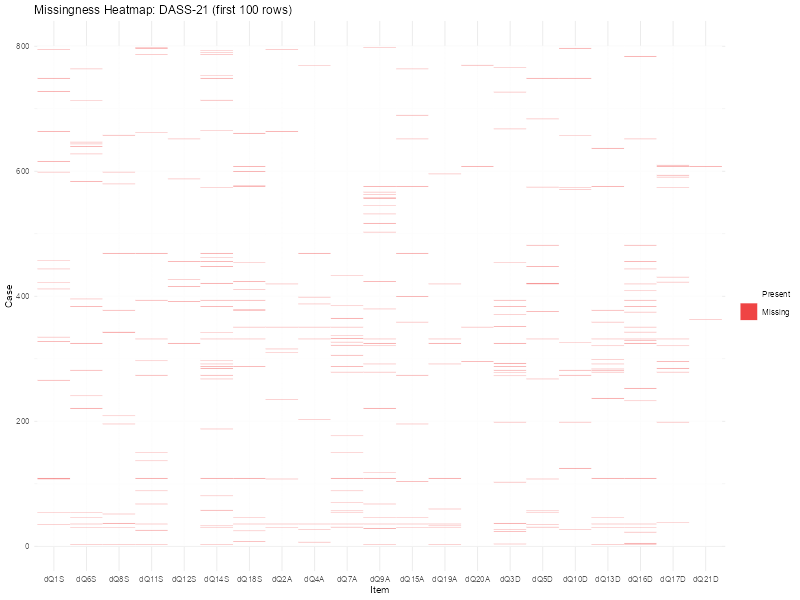

In [10]:
library(reshape2)
# Prepare the missingness matrix (first 100 rows)
miss_df21 <- as.data.frame(is.na(df21))
miss_mat <- miss_df21[1:800, ]
miss_long <- reshape2::melt(as.matrix(miss_mat))
# Column names are 'Var1' (row), 'Var2' (item), 'value' (missing TRUE/FALSE)

library(ggplot2)
ggplot(miss_long, aes(x = Var2, y = Var1, fill = value)) +
  geom_tile(color = "white") +
  scale_fill_manual(values = c("FALSE" = "white", "TRUE" = "#ef4444"), labels = c("Present", "Missing")) +
  labs(title = "Missingness Heatmap: DASS-21 (first 100 rows)", x = "Item", y = "Case", fill = "") +
  theme_minimal(base_size = 10)


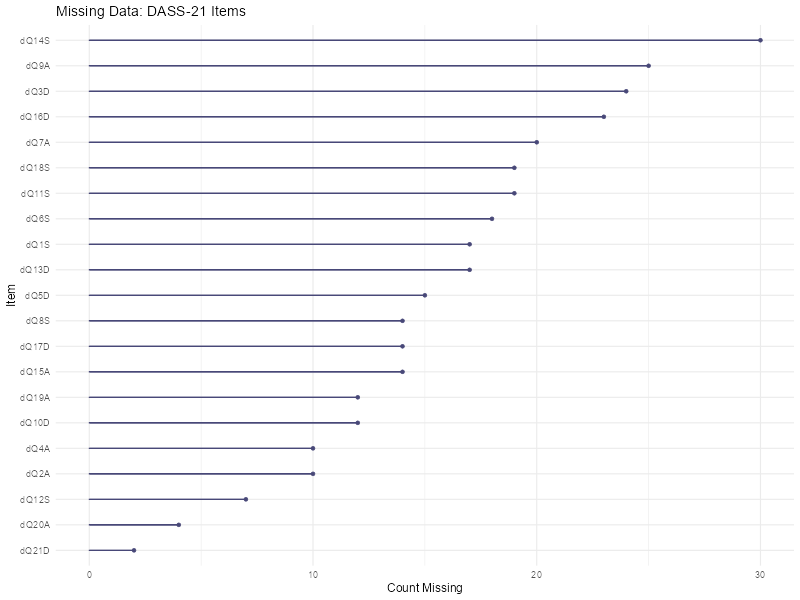

In [11]:
library(naniar)
gg_miss_var(df21) +
  labs(title = "Missing Data: DASS-21 Items", x = "Item", y = "Count Missing") +
  theme_minimal(base_size = 12)


In [16]:
suppressPackageStartupMessages({
  library(psych)
  library(dplyr)
  library(readr)
})

# Ensure numeric 0..3 input matrices (df21, df15 exist from your session)
to_num <- function(x) if (is.factor(x)) as.numeric(as.character(x)) else as.numeric(x)
df21c <- as.data.frame(lapply(df21, to_num))
df15c <- as.data.frame(lapply(df15, to_num))

# Drop rows with any missing to get a clean polychoric estimate
row_na21 <- apply(df21c, 1, function(z) any(is.na(z)))
row_na15 <- apply(df15c, 1, function(z) any(is.na(z)))
df21_complete <- df21c[!row_na21, , drop = FALSE]
df15_complete <- df15c[!row_na15, , drop = FALSE]

# 1) DASS-21: polychoric correlations + omega
cat("Omega reliability (ordinal): DASS-21\n")
pc21 <- psych::polychoric(df21_complete)  # returns list with $rho = polychoric R
# Option A: let omega compute from polychoric via poly=TRUE
omega21 <- psych::omega(df21_complete, nfactors = 3, poly = TRUE, plot = FALSE)
print(omega21)
# Option B: compute from correlation matrix directly (alternative)
# omega21 <- psych::omega(pc21$rho, nfactors = 3, plot = FALSE)

# Save to file
dir.create("outputs/PhaseC_field", recursive = TRUE, showWarnings = FALSE)
capture.output(omega21, file = file.path("outputs/PhaseC_field", "omega_DASS21.txt"))

# 2) DASS-15: polychoric correlations + omega
cat("Omega reliability (ordinal): DASS-15\n")
pc15 <- psych::polychoric(df15_complete)
omega15 <- psych::omega(df15_complete, nfactors = 3, poly = TRUE, plot = FALSE)
# Alternative using matrix: omega15 <- psych::omega(pc15$rho, nfactors = 3, plot = FALSE)
print(omega15)
capture.output(omega15, file = file.path("outputs/PhaseC_field", "omega_DASS15.txt"))


Omega reliability (ordinal): DASS-21
Omega 
Call: omegah(m = m, nfactors = nfactors, fm = fm, key = key, flip = flip, 
    digits = digits, title = title, sl = sl, labels = labels, 
    plot = plot, n.obs = n.obs, rotate = rotate, Phi = Phi, option = option, 
    covar = covar)
Alpha:                 0.89 
G.6:                   0.91 
Omega Hierarchical:    0.65 
Omega H asymptotic:    0.71 
Omega Total            0.91 

Schmid Leiman Factor loadings greater than  0.2 
         g   F1*   F2*   F3*    h2   h2   u2   p2  com
dQ1S  0.29                         0.12 0.88 0.69 1.88
dQ6S  0.45        0.32        0.31 0.31 0.69 0.65 1.87
dQ8S  0.58        0.46        0.55 0.55 0.45 0.60 1.98
dQ11S 0.54  0.30              0.43 0.43 0.57 0.68 1.95
dQ12S 0.43  0.25        0.28  0.33 0.33 0.67 0.57 2.41
dQ14S 0.34        0.42        0.32 0.32 0.68 0.36 2.25
dQ18S 0.47        0.35        0.35 0.35 0.65 0.64 1.88
dQ2A  0.31        0.21  0.20  0.21 0.21 0.79 0.47 3.16
dQ4A  0.47              0.48  0